In [7]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [8]:
import osmnx as ox
import geopandas as gpd
import pandas as pd
import city2graph as c2g
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import h3
import folium
from shapely.geometry import Polygon

In [9]:
place = "Bucharest, Romania"

g = ox.geocode_to_gdf(place)
print(g.geom_type.iloc[0], "—", g.iloc[0]["display_name"])
print(g.drop(columns="geometry")) 

g.explore()     

Polygon — Bucharest, Romania
   bbox_west  bbox_south  bbox_east  bbox_north  place_id  osm_type  osm_id  \
0  25.966674   44.334247  26.225577   44.541396  61427700  relation  377733   

         lat        lon     class            type  place_rank  importance  \
0  44.436141  26.102684  boundary  administrative           8     0.76123   

  addresstype       name        display_name  
0        city  Bucharest  Bucharest, Romania  


In [10]:


tag_groups = {
    "education": {"amenity": ["school", "kindergarten", "university", "college", "library"]},
    "health":    {"amenity": ["hospital", "clinic", "pharmacy", "doctors"], "healthcare": True},
    "green":     {"leisure": ["park", "playground", "garden", "sports_centre", "fitness_centre"]},
    "groceries": {"shop": ["supermarket", "convenience", "bakery", "greengrocer"],
                  "amenity": ["marketplace"]},
    "transit":   {"railway": ["station", "subway_entrance", "tram_stop"], "highway": ["bus_stop"]},
    "culture":   {"amenity": ["cafe", "restaurant", "bar", "cinema", "theatre"],
                  "tourism": ["museum", "gallery"]},
    "services":  {"amenity": ["bank", "atm", "post_office"]}
}

area = ox.geocode_to_gdf(place).geometry.iloc[0]

def fetch(cat, tags):
    g = ox.features_from_polygon(area, tags=tags)
    g["poi_category"] = cat
    return g.to_crs(4326)

frames = []
with ThreadPoolExecutor(max_workers=3) as ex:                 
    futures = {ex.submit(fetch, c, t): c for c, t in tag_groups.items()}
    for fut in as_completed(futures):
        cat = futures[fut]
        try:
            frames.append(fut.result())
        except Exception as e:                                
            print(f"{cat} failed: {e}")                       

pois = gpd.GeoDataFrame(pd.concat(frames), crs=4326)

display(pois)

geometry  \
element id                                                             
node    218092022                           POINT (26.17836 44.4422)   
        271285333                          POINT (26.06146 44.42082)   
        444361321                          POINT (26.05532 44.48421)   
        494791040                          POINT (26.11326 44.43714)   
        501932616                          POINT (26.09828 44.42606)   
...                                                              ...   
way     217416250  POLYGON ((26.09474 44.38702, 26.09511 44.38712...   
        219735025  POLYGON ((26.07845 44.49554, 26.07874 44.49554...   
        318990256  POLYGON ((26.11851 44.48117, 26.11866 44.48122...   
        405520011  POLYGON ((26.08318 44.45251, 26.08334 44.4524,...   
        948792755  POLYGON ((26.03568 44.43451, 26.03568 44.43448...   

                        amenity                           name  addr:city  \
element id                                                                  
node    218092022  kindergarten               Grădinița nr. 23        NaN   
        271285333        school    Liceul Teoretic "Ion Barbu"  București   
        444361321        school                 School no. 178        NaN   
        494791040        school     Colegiul Economic "Hermes"  București   
        501932616  kindergarten            Grădinița Prikindel        NaN   
...                         ...                            ...        ...   
way     217416250   post_office  Centrala Telefonică Giurgiu 1        NaN   
        219735025          bank             Banca Transilvania  București   
        318990256          bank                            BCR  București   
        405520011          bank                            BRD  București   
        948792755          bank                            BCR  București   

                  addr:housenumber                  addr:street grades  \
element id                                                               
node    218092022              NaN                          NaN    NaN   
        271285333               18             Strada Năbucului   0-12   
        444361321              NaN                          NaN    NaN   
        494791040              152                Calea Moșilor    NaN   
        501932616              NaN                          NaN    NaN   
...                            ...                          ...    ...   
way     217416250              NaN                          NaN    NaN   
        219735025               43   Șoseaua București-Ploiești    NaN   
        318990256                6  Bulevardul Dimitrie Pompeiu    NaN   
        405520011              1-7     Bulevardul Ion Mihalache    NaN   
        948792755               22       Bulevardul Iuliu Maniu    NaN   

                                             website addr:country  \
element id                                                          
node    218092022                                NaN          NaN   
        271285333               https://www.ltib.ro/          NaN   
        444361321                                NaN          NaN   
        494791040                                NaN           RO   
        501932616                                NaN          NaN   
...                                              ...          ...   
way     217416250                                NaN          NaN   
        219735025  https://www.bancatransilvania.ro/           RO   
        318990256                                NaN          NaN   
        405520011                                NaN          NaN   
        948792755                                NaN          NaN   

                  addr:postcode  ... currency:USDT currency:XBT  \
element id                       ...                              
node    218092022           NaN  ...           NaN          NaN   
        271285333           NaN  ...           NaN         

In [11]:
G_w = ox.graph_from_polygon(area, network_type="all")

In [12]:
street_nodes, street_edges = ox.graph_to_gdfs(G_w)

print(len(street_nodes), "intersections |", len(street_edges), "street segments")

65285 intersections | 161274 street segments


KeyboardInterrupt: 

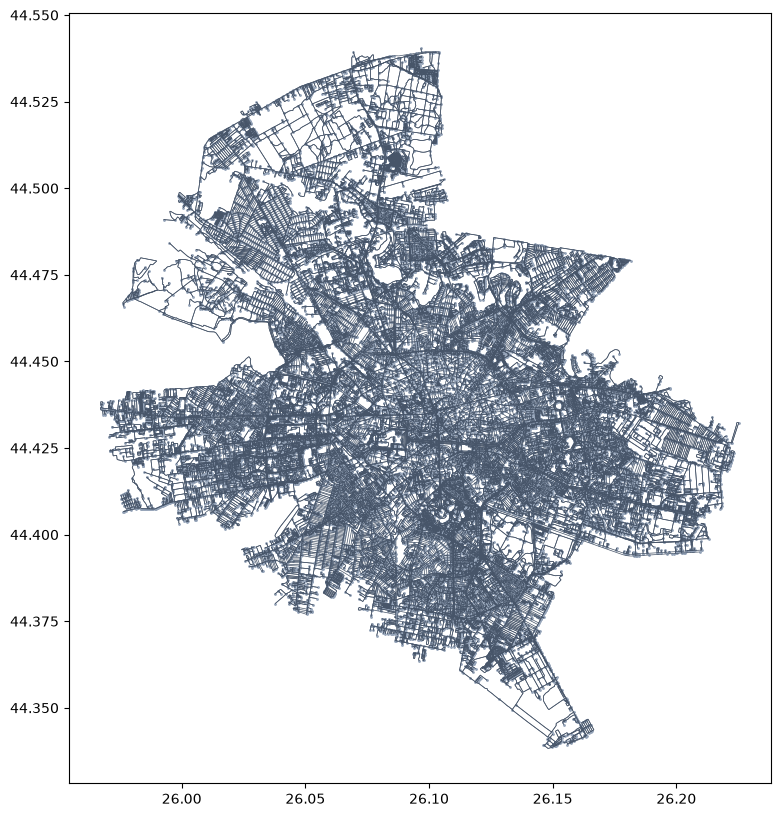

In [13]:
fig, ax = plt.subplots(figsize=(10, 10))

street_edges.plot(ax=ax, color="#475569", linewidth=0.5)       
street_nodes.plot(ax=ax, color="#94a3b8", markersize=1)       
pois.plot(ax=ax, column="poi_category", markersize=6,           
          legend=True, cmap="tab10")

ax.set_axis_off()
ax.set_aspect("equal")
plt.title("Bucharest — streets + POIs")
fig.savefig("bucharest_map.svg", format="svg", bbox_inches="tight")
plt.show()

In [ ]:
m = street_edges.explore(color="#475569", style_kwds={"weight": 1},
                         name="Streets", tiles="CartoDB positron")
pois.explore(m=m, column="poi_category", cmap="tab10",
             marker_kwds={"radius": 3},
             tooltip=["poi_category", "name"], name="POIs")
folium.LayerControl().add_to(m)

m

In [ ]:

def make_hexgrid(boundary_gdf, res=9):
    aoi = boundary_gdf.to_crs(4326).union_all()          
    cells = h3.geo_to_cells(aoi, res)                    

    def cell_poly(c):
        return Polygon([(lng, lat) for lat, lng in h3.cell_to_boundary(c)])

    grid = gpd.GeoDataFrame({"h3_index": list(cells)},
                            geometry=[cell_poly(c) for c in cells], crs=4326)
    return grid

grid = make_hexgrid(g, res=9)     
print(len(grid), "cells")
print(grid)

grid.explore(tiles="CartoDB positron",
             style_kwds={"color": "#3b82f6", "weight": 0.5, "fillOpacity": 0.06})